In [2]:
from azureml.core import Workspace, Dataset, Datastore
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

# اتصال به Azure ML Workspace
subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'

workspace = Workspace(subscription_id, resource_group, workspace_name)

# دریافت Datastore و Dataset
datastore = Datastore.get(workspace, "researcher_data")
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/XGboost/MDP/Bleed/Evaluate/predictions.csv')
)

# تبدیل Dataset به DataFrame
df = dataset.to_pandas_dataframe()


Timeout was exceeded in force_flush().
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


Resolving access token for scope "https://storage.azure.com/.default" using identity of type "MANAGED".
Getting data access token with Assigned Identity (client_id=clientid) and endpoint type based on configuration
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}


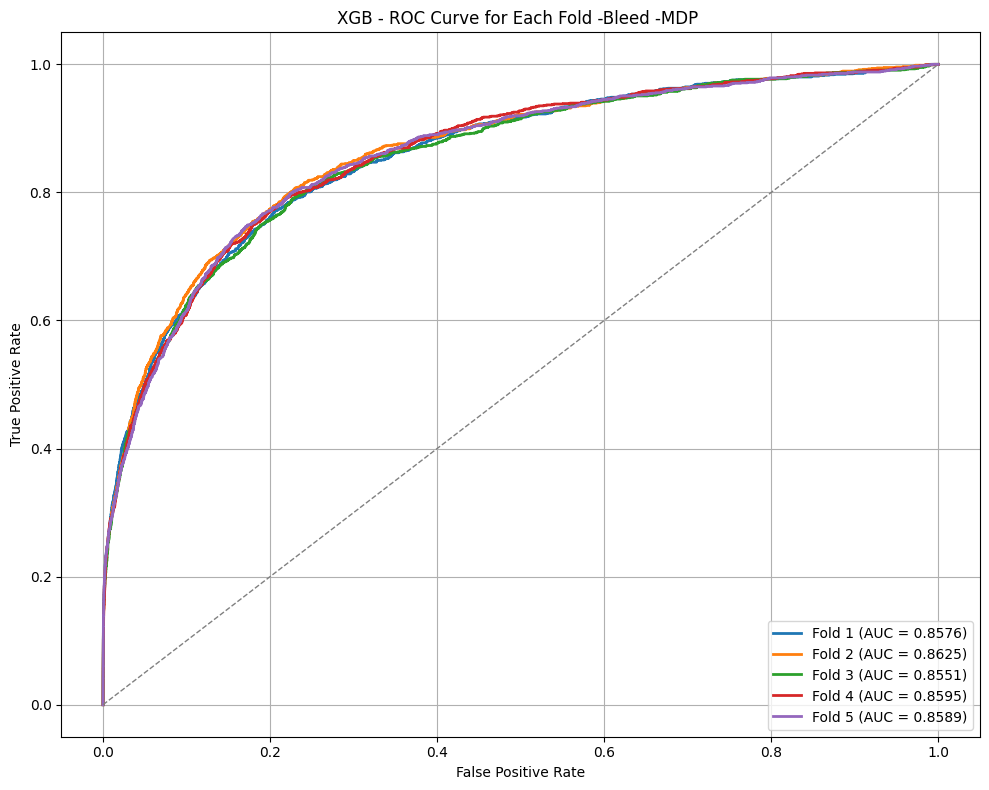

In [4]:
from azureml.core import Workspace, Dataset, Datastore
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

# اتصال به Azure ML Workspace
subscription_id = 'f8c5aac3-29fc-4387-858a-1f61722fb57a'
resource_group = 'forskerpl-n0ybkr-rg'
workspace_name = 'forskerpl-n0ybkr-mlw'

workspace = Workspace(subscription_id, resource_group, workspace_name)

# دریافت Datastore و Dataset
datastore = Datastore.get(workspace, "researcher_data")
dataset = Dataset.Tabular.from_delimited_files(
    path=(datastore, 'Zahra/XGboost/MDP/Bleed/Evaluate/predictions.csv')
)

# تبدیل Dataset به DataFrame
df = dataset.to_pandas_dataframe()

# لیست ستون‌های پروبایلیتی
fold_cols = ['fold_1_probas', 'fold_2_probas', 'fold_3_probas', 'fold_4_probas', 'fold_5_probas']

# رسم همه ROCها
plt.figure(figsize=(10, 8))

for i, col in enumerate(fold_cols, 1):
    fpr, tpr, _ = roc_curve(df['target'], df[col])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Fold {i} (AUC = {roc_auc:.4f})')

# اضافه کردن baseline و تنظیمات گراف
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGB - ROC Curve for Each Fold -Bleed -MDP ')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()
